<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/MOD-2/04_Decision_Tree/exercise_decision_tree_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees and Ensemble Methods

## Learning Objectives

1. Understand how Decision Trees perform classification
2. Train and visualize a Decision Tree classifier
3. Explain the role of pruning in preventing overfitting
4. Analyze instability in feature selection and tree structure
5. Improve classification performance using ensemble methods
6. Compare Decision Trees, Random Forests, and AdaBoost classifiers

## 1. Imports and Dataset

Run the following cell to import libraries and dataset. The dataset includes 30 features, related to the characteristics of a tumor tissue, and the corresponding classification of the tumor as benign or malignant:
* X = dataframe of input features
* y = class (0 = benign; 1 = tumor)
* features = the list of feature names
* class_names = the name of the two classes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Load biomedical dataset
data = load_breast_cancer() # load raw breast cancer dataset structure

X = pd.DataFrame(data.data, columns=data.feature_names) # convert features into a structured pandas dataframe
y = pd.Series(data.target, name="target") # convert target array into a pandas series

features = X.columns # extract data feature column names
class_names = ['benign', 'tumor'] # map categorical class targets to explicit text representations
print('Feature names:', features) # print out all available feature names
print('Number of samples:', X.shape[0]) # print out the total row count in the dataset
print('Number of tumor samples:', np.sum(y == 1)) # print out the total number of positive instances

Feature names: Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')
Number of samples: 569
Number of tumor samples: 357


## 2. Train/Test Split
* Split the dataset into train and test (30%)

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
) # split the dataset into stratified train and test subsets using a 70/30 ratio

print("Training samples:", X_train.shape[0]) # print the total number of samples allocated to training
print("Testing samples:", X_test.shape[0]) # print the total number of samples allocated to testing

Training samples: 398
Testing samples: 171


## 3. Complete Decision Tree

* Train a model of the class DecisionTreeClassifier without any pruning
* Evaluate its performance in the testing and training set
* Use the function plot_tree to visualize the  decision tree. Usefull parameters to improve the quality of the figures are: filled, fontsize, feature_names, max_depth, and class_names. Another suggestion is to manually define the size of the figure in the command plt.figure (example: plt.*figure(figsize=(20, 10))*)

Training accuracy: 1.0
Testing accuracy: 0.9181286549707602


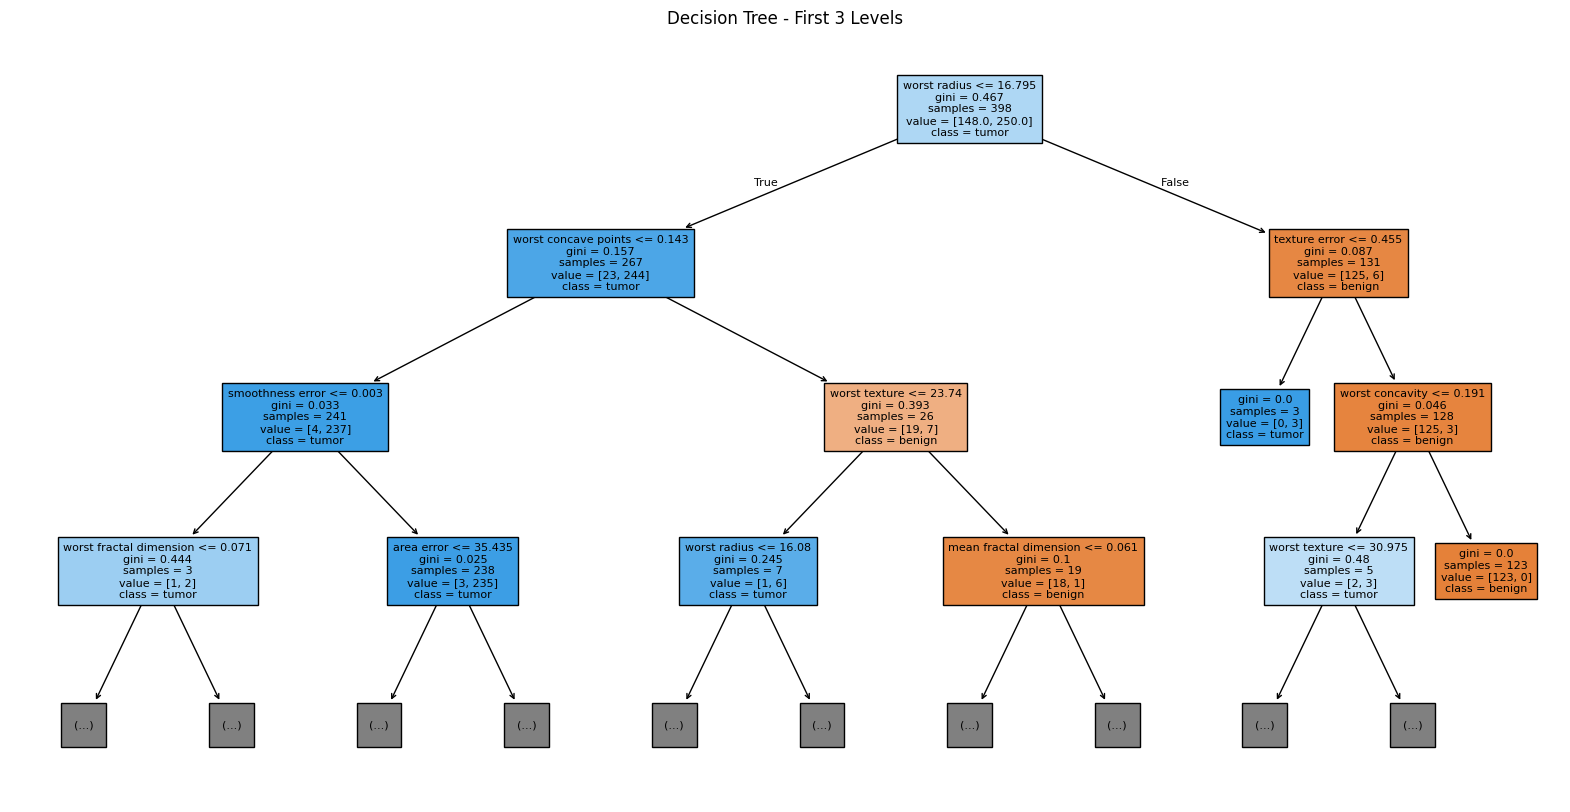

In [3]:
tree = DecisionTreeClassifier(random_state=42) # initialize decision tree model with a fixed random seed
tree.fit(X_train, y_train) # train the decision tree classifier on training data

y_pred_train = tree.predict(X_train) # generate predictions for the training set records
y_pred_test = tree.predict(X_test) # generate predictions for the testing set records

print("Training accuracy:", accuracy_score(y_train, y_pred_train)) # evaluate and print performance on training records
print("Testing accuracy:", accuracy_score(y_test, y_pred_test)) # evaluate and print generalization performance on test records

plt.figure(figsize=(20, 10)) # initialize a wide canvas layout for tree structure plotting
plot_tree(
    tree,
    feature_names=features,
    class_names=class_names,
    filled=True,
    max_depth=3,
    fontsize=8
) # render tree node structures up to the third level with colored condition splits
plt.title("Decision Tree - First 3 Levels") # add a descriptive header to the generated plot
plt.show() # display the final decision tree graph layout

## 4. Cost-Complexity Pruning

The hyperparameter `ccp_alpha` penalizes large trees.

The pruning objective is:

$$
R_\alpha(T) = R(T) + \alpha |T|
$$

where:

- R(T): classification error
- |T|: number of terminal nodes
- alpha: pruning strength

Larger values of `ccp_alpha` produce simpler trees.

* Use cross-validation to train a regularized decision tree. Test the following alpha values: \[0.0, 0.001, 0.005, 0.01, 0.02\]
* Report accuracy in the training and testing set
* Compare the regularized tree with the one defined before

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
) # initialize a 5-fold stratified cross-validation splitter with shuffling
param_grid = {
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01, 0.02]
} # define candidate parameters for cost-complexity pruning to control overfitting
dt_cv = DecisionTreeClassifier(random_state=42) # instantiate a base decision tree classifier with a fixed seed
grid_search = GridSearchCV(
    estimator=dt_cv,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
) # configure parallel grid search over alpha values tracking both train and test scores
grid_search.fit(X_train, y_train) # execute the cross-validated parameter sweep on the training set
print("Best cross-validation accuracy:", grid_search.best_score_) # print the optimal average score achieved during validation
print("Best pruning parameters:", grid_search.best_params_) # print the specific alpha parameter that yielded the highest accuracy
best_model = grid_search.best_estimator_ # extract the optimal pruned tree model trained on the full training set
y_pred_train_pruned = best_model.predict(X_train) # generate predictions for the training set using the best model
y_pred_test_pruned = best_model.predict(X_test) # generate predictions for the testing set using the best model
print("Training accuracy:", accuracy_score(y_train, y_pred_train_pruned)) # calculate and print accuracy on the training split
print("Testing accuracy:", accuracy_score(y_test, y_pred_test_pruned)) # calculate and print generalization accuracy on the test split

Best cross-validation accuracy: 0.9421835443037974
Best pruning parameters: {'ccp_alpha': 0.005}
Training accuracy: 0.9849246231155779
Testing accuracy: 0.9298245614035088


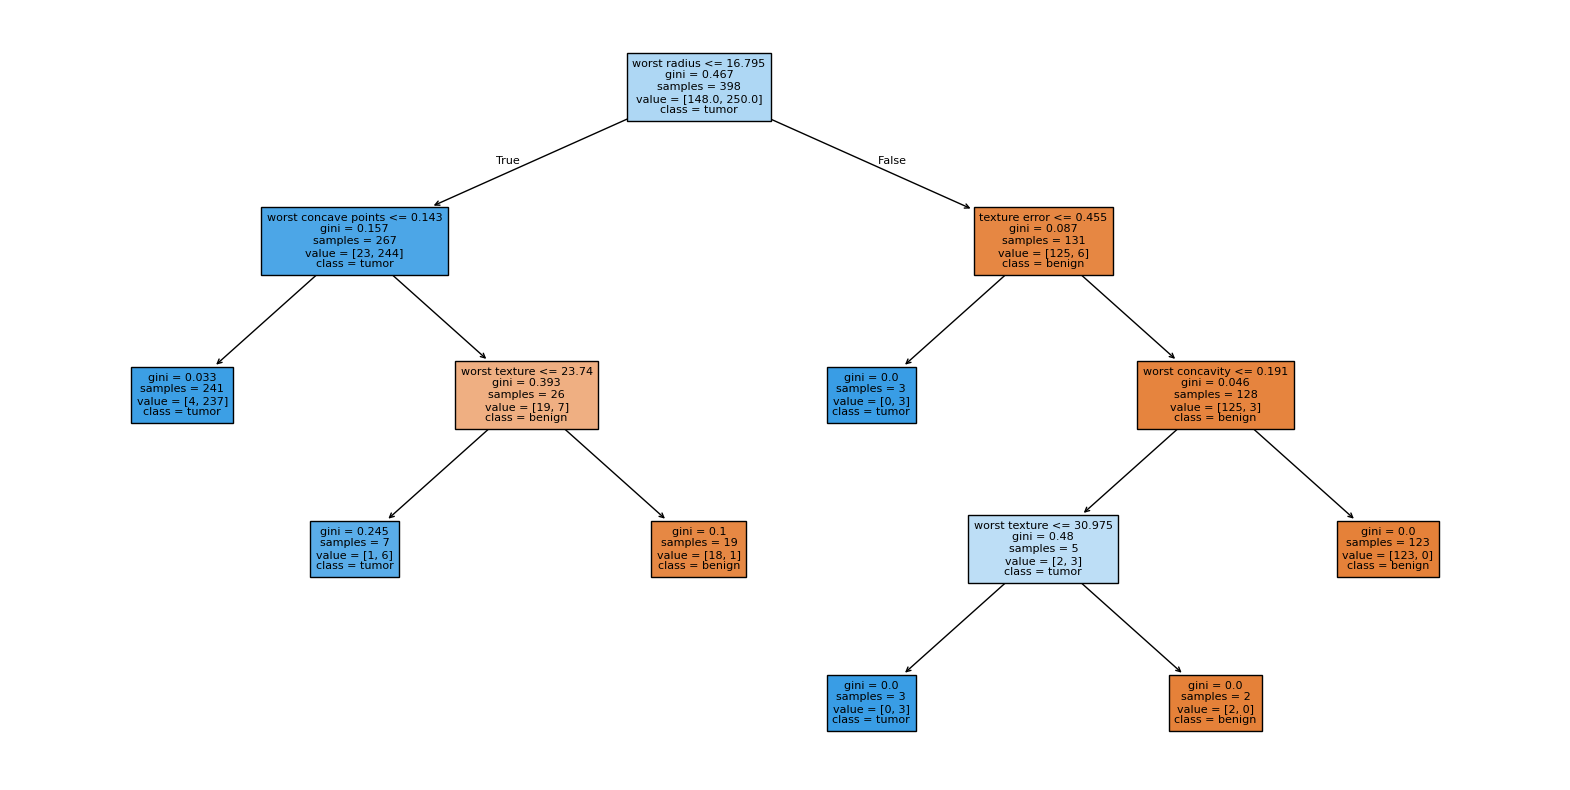

In [5]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=features,
    class_names=class_names,
    filled=True,
    fontsize=8
)
plt.show()

## 5. Instability of Decision Trees

Decision Trees are unstable learners.

Small changes in the training data may produce different tree structures and feature importances.

* Train two Decision Trees with parameter max_depth equal to 3 using different random splits of training and testing sets
* Plot the importance of the features (attribute .feature_importances_) for the two trees

Text(0.5, 1.0, 'Tree2')

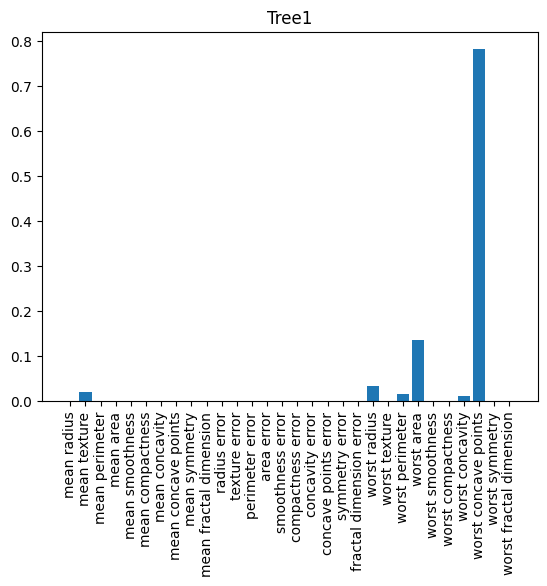

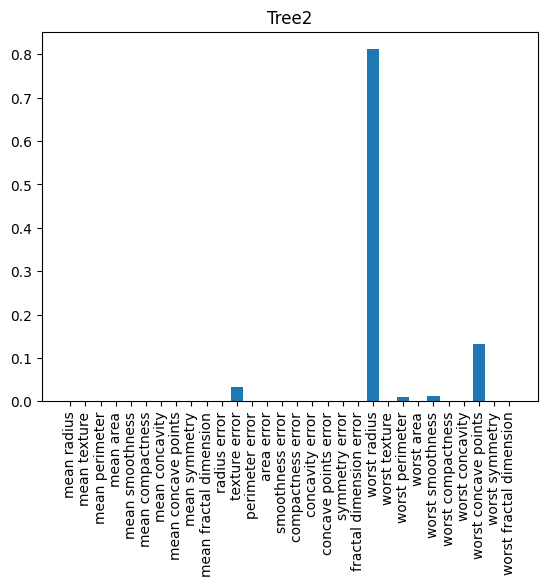

In [6]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1,
    stratify=y
) # create first data split with seed 1 to demonstrate variance

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=10,
    stratify=y
) # create second data split with seed 10 to compare against the first

tree1 = DecisionTreeClassifier(max_depth=3, random_state=42) # initialize first decision tree constrained to max depth 3
tree2 = DecisionTreeClassifier(max_depth=3, random_state=42) # initialize second decision tree constrained to max depth 3

tree1.fit(X_train1, y_train1) # train the first model on the first training split
tree2.fit(X_train2, y_train2) # train the second model on the second training split

f = plt.figure() # initialize a new figure object for the first tree's plot
ax1 = f.add_subplot(1,1,1) # add a single subplot axis to the figure
ax1.bar(np.arange(len(features)), tree1.feature_importances_) # plot first tree's feature importances as vertical bars
ax1.set_xticks(np.arange(len(features))) # set x-axis tick positions corresponding to each feature
ax1.set_xticklabels(features, rotation=90) # apply feature names as x-axis labels rotated 90 degrees
plt.title('Tree1') # set a descriptive title for the first plot

f = plt.figure() # initialize a new figure object for the second tree's plot
ax1 = f.add_subplot(1,1,1) # add a single subplot axis to the figure
ax1.bar(np.arange(len(features)), tree2.feature_importances_) # plot second tree's feature importances as vertical bars
ax1.set_xticks(np.arange(len(features))) # set x-axis tick positions corresponding to each feature
ax1.set_xticklabels(features, rotation=90) # apply feature names as x-axis labels rotated 90 degrees
plt.title('Tree2') # set a descriptive title for the second plot

## 6. Random Forests

Random Forests train many Decision Trees using:

- Bootstrap sampling
- Random feature subsets

For classification, the final prediction is usually obtained by majority vote.

The main idea is that combining many unstable trees creates a more stable and accurate classifier.

* Train a random forest classifier (class RandomForestClassifier) using the following parameters:
  * n_estimators = 100
  * max_depth = 5
* Report the accuracy in the training and testing set
* Repeat the previous analysis about the stability of features'importance in two separate training set

In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
) # initialize a random forest classifier with 100 decision trees and a max depth of 5
rf.fit(X_train, y_train) # train the random forest ensemble on the training data split

y_pred_train_rf = rf.predict(X_train) # generate class predictions for the training set records
y_pred_test_rf = rf.predict(X_test) # generate class predictions for the testing set records

print("Training accuracy:", accuracy_score(y_train, y_pred_train_rf)) # calculate and print performance metrics on the training set
print("Testing accuracy:", accuracy_score(y_test, y_pred_test_rf)) # evaluate and print generalization accuracy on the unseen test set

Training accuracy: 0.992462311557789
Testing accuracy: 0.9415204678362573


Text(0.5, 1.0, 'Tree2')

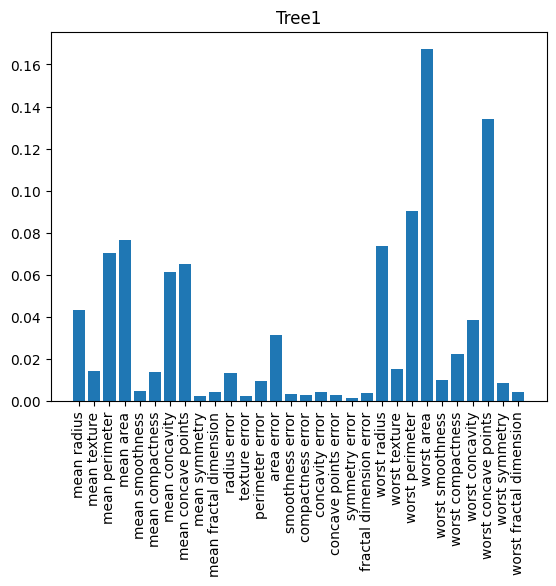

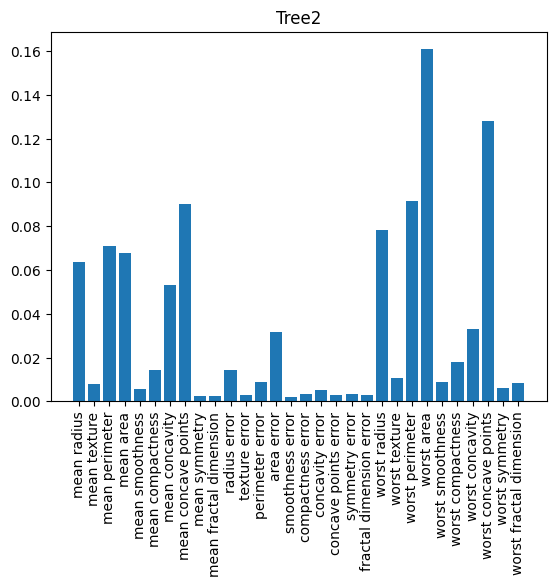

In [8]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1,
    stratify=y
) # create first data split with seed 1 to evaluate ensemble variance

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=10,
    stratify=y
) # create second data split with seed 10 to compare feature weights

tree1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42) # initialize first random forest ensemble model
tree2 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42) # initialize second random forest ensemble model

tree1.fit(X_train1, y_train1) # train the first forest ensemble on the first training split
tree2.fit(X_train2, y_train2) # train the second forest ensemble on the second training split

f = plt.figure() # initialize a new figure object for the first forest plot
ax1 = f.add_subplot(1,1,1) # add a single subplot axis to the figure layout
ax1.bar(np.arange(len(features)), tree1.feature_importances_) # plot feature importances computed by the first forest model
ax1.set_xticks(np.arange(len(features))) # set x-axis tick positions corresponding to each feature coordinate
ax1.set_xticklabels(features, rotation=90) # apply feature names as x-axis labels rotated 90 degrees
plt.title('Tree1') # set a descriptive title for the first plot layout

f = plt.figure() # initialize a new figure object for the second forest plot
ax1 = f.add_subplot(1,1,1) # add a single subplot axis to the figure layout
ax1.bar(np.arange(len(features)), tree2.feature_importances_) # plot feature importances computed by the second forest model
ax1.set_xticks(np.arange(len(features))) # set x-axis tick positions corresponding to each feature coordinate
ax1.set_xticklabels(features, rotation=90) # apply feature names as x-axis labels rotated 90 degrees
plt.title('Tree2') # set a descriptive title for the second plot layout

Each tree in the Random Forest has its own feature importance vector.

For each feature, we compute:

$$
SE_j = \frac{s_j}{\sqrt{M}}
$$

where:

- s_j is the standard deviation of feature importance across trees,
- M is the number of trees.

* Compute the average and the standard error of the feature importance. The trees are available from the attribute .estimators_ of the random forest object
* Plot the average feature importance with the corresponding standard error

Text(0.5, 1.0, 'Tree2')

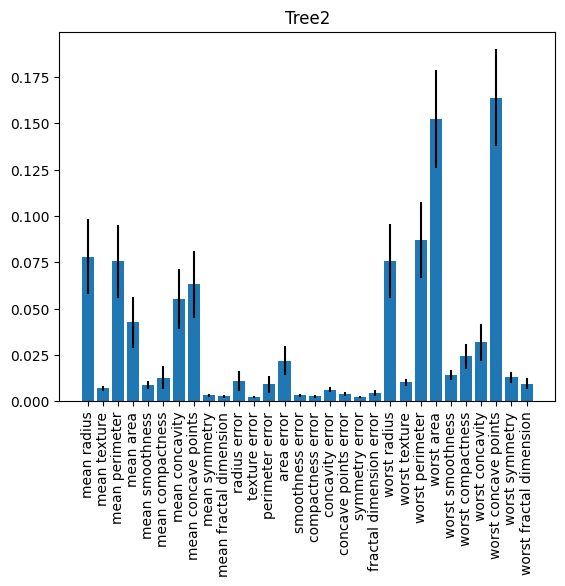

In [9]:
rf_tree_importances = np.array([
    estimator.feature_importances_
    for estimator in rf.estimators_
]) # extract feature importances from each individual decision tree in the random forest ensemble

rf_mean_importance = rf_tree_importances.mean(axis=0) # compute the average feature importance across all individual trees
rf_std_importance = rf_tree_importances.std(axis=0, ddof=1) # calculate the sample standard deviation of feature importances
rf_se_importance = rf_std_importance / np.sqrt(rf_tree_importances.shape[0]) # compute the standard error of the mean for feature importances

f = plt.figure() # initialize a new figure object for the ensemble feature importance plot
ax1 = f.add_subplot(1,1,1) # add a single subplot axis to the layout structure
ax1.bar(np.arange(len(features)), rf_mean_importance, yerr= rf_se_importance ) # plot mean importances as vertical bars with standard error lines
ax1.set_xticks(np.arange(len(features))) # set x-axis tick locations corresponding to each feature coordinate
ax1.set_xticklabels(features, rotation=90) # apply feature names as x-axis labels rotated 90 degrees
plt.title('Tree2') # set a descriptive title for the aggregate importance plot

## 17. Adaptive Boosting

AdaBoost sequentially trains weak learners, with the hey idea that misclassified samples receive larger weights, and consequenlty new classifiers focus more strongly on difficult cases. The final classifier combines weighted predictions from all weak learners.

* Train an Adaptive Boosting classifier (class AdaBoost) using the following parameters:
  * n_estimators = 100
  * learning_rate = 0.5
* Report the accuracy in the training and testing set

In [10]:
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
) # initialize an adaboost classifier with 100 weak estimators and a 0.5 learning rate
ada.fit(X_train, y_train) # train the adaboost ensemble model on the training data split
y_pred_train_rf = ada.predict(X_train) # generate class predictions for the training set records
y_pred_test_rf = ada.predict(X_test) # generate class predictions for the testing set records
print("Training accuracy:", accuracy_score(y_train, y_pred_train_rf)) # calculate and print performance metrics on the training set
print("Testing accuracy:", accuracy_score(y_test, y_pred_test_rf)) # evaluate and print generalization accuracy on the unseen test set

Training accuracy: 1.0
Testing accuracy: 0.9532163742690059
